# Análisis de Factores de Contaminación de aire (Lima Metropolitana)

# Carga de Datos

## Configuración del entorno

In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import numpy as np

RUTA_DATOS = "../data/air_contamination.csv"
RUTA_LIMPIO = "../data/air_contamination_clean.parquet"

from core.preprocessing import SEED
np.random.seed(SEED)

Dataset utilizado:

\*\* Datos Horarios de Contanimantes del Aire en Lima Metropolitana
\[Servicio Nacional de Meteorología e Hidrología del Perú -
senamhi\]\*\*

Enlace:
`https://www.datosabiertos.gob.pe/dataset/datos-horarios-de-contanimantes-del-aire-en-lima-metropolitana-servicio-nacional-de`

In [2]:
from core.preprocessing import cargar_datos, CONTAMINANTES

df = cargar_datos(RUTA_DATOS)

print("Filas, columnas:", df.shape)
print("Estaciones:", sorted(df["estacion"].unique()))
print("Rango de fechas:", df["fecha_hora"].min(), "a", df["fecha_hora"].max())

Filas, columnas: (703056, 13)
Estaciones: ['ATE', 'CAMPO DE MARTE', 'CARABAYLLO', 'HUACHIPA', 'PUENTE PIEDRA', 'SAN BORJA', 'SAN JUAN DE LURIGANCHO', 'SAN MARTIN DE PORRES', 'SANTA ANITA', 'VILLA MARIA DEL TRIUNFO']
Rango de fechas: 2010-04-01 00:00:00 a 2020-09-30 23:00:00


## Diagnóstico base

In [3]:
print("% de nulos por columna")
print((
  df[CONTAMINANTES].isna().mean() * 100
).round(1))

% de nulos por columna
pm_10    29.4
pm_25    51.6
so2      58.1
no2      50.0
o3       50.4
co       54.3
dtype: float64


Se evidencia que pm_25 tiene el mayor porcentaje de nulos (51%) Así que
se empezará a anlizar

In [4]:
nulos_pm_25_por_anio = df.groupby(df["fecha_hora"].dt.year)["pm_25"].apply(
  lambda s: s.isna().mean()*100
)
print("% de nulos por año para pm_25")
print(nulos_pm_25_por_anio.round(1))

% de nulos por año para pm_25
fecha_hora
2010    100.0
2011    100.0
2012    100.0
2013    100.0
2014     50.3
2015     16.5
2016     27.0
2017     25.0
2018     41.1
2019     66.8
2020     66.2
Name: pm_25, dtype: float64


**Observación:** No existe pm_25 antes de 2014

In [5]:
print("\nHoras faltantes como fila, por estación:")
for est, g in df.groupby("estacion"):
    esperado = pd.date_range(g["fecha_hora"].min(), g["fecha_hora"].max(), freq="h")
    faltan = len(esperado) - g["fecha_hora"].nunique()
    print(f"  {est}: {faltan} de {len(esperado)} ({faltan/len(esperado)*100:.2f}%)")


Horas faltantes como fila, por estación:
  ATE: 1 de 92064 (0.00%)
  CAMPO DE MARTE: 1 de 89136 (0.00%)
  CARABAYLLO: 1 de 57000 (0.00%)
  HUACHIPA: 0 de 45600 (0.00%)
  PUENTE PIEDRA: 1 de 56784 (0.00%)
  SAN BORJA: 1 de 90600 (0.00%)
  SAN JUAN DE LURIGANCHO: 1 de 56640 (0.00%)
  SAN MARTIN DE PORRES: 1 de 57000 (0.00%)
  SANTA ANITA: 1 de 81528 (0.00%)
  VILLA MARIA DEL TRIUNFO: 1 de 76704 (0.00%)


In [6]:
dup = df.duplicated(subset=["estacion", "fecha_hora"], keep=False)
print(f"\nFilas en duplicados de (estación, timestamp): {dup.sum()}")
print(df.loc[dup, ["estacion", "fecha_hora"] + CONTAMINANTES].sort_values(["estacion", "fecha_hora"]))


Filas en duplicados de (estación, timestamp): 18
                       estacion fecha_hora  pm_10  pm_25   so2   no2    o3  \
82512                       ATE 2019-08-30    NaN    NaN   NaN   NaN   NaN   
82536                       ATE 2019-08-30    NaN    NaN   NaN   NaN   NaN   
262248           CAMPO DE MARTE 2019-08-30  48.71  45.15   NaN   NaN  23.9   
262272           CAMPO DE MARTE 2019-08-30  33.33  31.00   NaN   NaN  30.8   
636720               CARABAYLLO 2019-08-30    NaN    NaN   5.0  10.4   NaN   
636744               CARABAYLLO 2019-08-30    NaN    NaN   5.0   7.6   NaN   
693504            PUENTE PIEDRA 2019-08-30    NaN    NaN   NaN  38.6   NaN   
693528            PUENTE PIEDRA 2019-08-30    NaN    NaN   NaN  32.7   NaN   
173112                SAN BORJA 2019-08-30    NaN    NaN   NaN  16.1   NaN   
173136                SAN BORJA 2019-08-30    NaN    NaN   NaN  15.7   NaN   
522720   SAN JUAN DE LURIGANCHO 2019-08-30    NaN    NaN  13.4  54.5   5.6   
522744   SAN J

### Revisión de pm_25 y Fecha de Corte

pm_25 no existe antes de 2014, pero se requiere el mes aproximado para el recorte del dataset

In [7]:
df_2014 = df[df["fecha_hora"].dt.year == 2014]
nulos_pm25_2014 = df_2014.groupby(df_2014["fecha_hora"].dt.month)["pm_25"].apply(
    lambda s: s.isna().mean() * 100
)
print("% de nulos en pm_25 por mes, solo 2014:")
print(nulos_pm25_2014.round(1))

% de nulos en pm_25 por mes, solo 2014:
fecha_hora
1     100.0
2     100.0
3     100.0
4      58.1
5      56.7
6      53.2
7      51.1
8      50.0
9      57.8
10     22.7
11     21.5
12      9.6
Name: pm_25, dtype: float64


En 2014, el % de nulos de pm_25 case de ~50-58% a 22.7% (oct) por lo que se toma Octubre de 2014 (10-2014) como fecha de corte

### Constantes finales

In [8]:
from core.preprocessing import FECHA_CORTE, LIMITE_INTERPOLACION_HORAS

print("FECHA_CORTE:", FECHA_CORTE)
print("LIMITE_INTERPOLACION_HORAS:", LIMITE_INTERPOLACION_HORAS)

FECHA_CORTE: 2014-10-01 00:00:00
LIMITE_INTERPOLACION_HORAS: 6


### Huecos de la serie en Tiempos

In [9]:
df_ventana = df[df["fecha_hora"] >= FECHA_CORTE].copy()
def duracion_huecos(serie):
    es_nulo = serie.isna()
    grupo = (es_nulo != es_nulo.shift()).cumsum()
    rachas = es_nulo.groupby(grupo).sum()
    return rachas[rachas > 0]

duraciones = df_ventana.groupby("estacion")["pm_25"].apply(duracion_huecos).reset_index(drop=True)
print("Distribución de duración de huecos en pm_25 (horas consecutivas):")
print(duraciones.describe())

Distribución de duración de huecos en pm_25 (horas consecutivas):
count     1104.000000
mean       176.149457
std        841.060857
min          1.000000
25%          1.000000
50%          6.000000
75%         46.000000
max      10766.000000
Name: pm_25, dtype: float64


La mediana es 6h, verifiquemos los huecos relacionados a esa medida (x0.5 y x2)

In [10]:
print("\n% de huecos que duran 3h o menos:", round((duraciones <= 3).mean() * 100, 1))
print("% de huecos que duran 6h o menos:", round((duraciones <= 6).mean() * 100, 1))
print("% de huecos que duran 12h o menos:", round((duraciones <= 12).mean() * 100, 1))
print("% de huecos que duran 24h o menos:", round((duraciones <= 24).mean() * 100, 1))


% de huecos que duran 3h o menos: 44.9
% de huecos que duran 6h o menos: 54.9
% de huecos que duran 12h o menos: 64.1
% de huecos que duran 24h o menos: 69.5


Se especificará 6h ya que es el valor mas razonable (12 es medio día de perdida y 3h deja más carga a la inputación)

## Limpieza e Inputación

### Filtrar ventana

In [11]:
from core.preprocessing import limpiar_e_imputar

df_full = limpiar_e_imputar(df)

## Dataset limpio

In [12]:
df_full.to_parquet(RUTA_LIMPIO, index=False)
print("Guardado en:", RUTA_LIMPIO)
print("Shape final:", df_full.shape)
df_full.head()


Guardado en: ../data/air_contamination_clean.parquet
Shape final: (514680, 18)


,fecha_hora,estacion,codigo_estacion,pm_10,pm_25,so2,no2,o3,co,mes,hora,anio,pm_10_imputado,pm_25_imputado,so2_imputado,no2_imputado,o3_imputado,co_imputado
0,2014-10-01 00:00:00,ATE,112192.0,116.26,43.2,21.4,42.20,5.00,1422.30,10,0,2014,False,False,True,True,True,True
1,2014-10-01 01:00:00,ATE,112192.0,125.31,45.5,22.1,40.65,5.00,1358.00,10,1,2014,False,False,True,True,True,True
2,2014-10-01 02:00:00,ATE,112192.0,124.78,54.5,22.8,38.40,5.05,1288.70,10,2,2014,False,False,True,True,True,True
3,2014-10-01 03:00:00,ATE,112192.0,144.21,66.8,23.5,38.20,5.30,1228.45,10,3,2014,False,False,True,True,True,True
4,2014-10-01 04:00:00,ATE,112192.0,159.18,76.8,21.4,38.25,5.10,1167.65,10,4,2014,False,False,True,True,True,True


## EDA - Estadísticas Descriptivas

In [13]:
df_full[CONTAMINANTES].describe().round(2)

,pm_10,pm_25,so2,no2,o3,co
count,514680.00,514680.00,514680.00,514680.00,514680.00,514680.00
mean,78.46,25.38,10.77,24.86,14.40,852.22
std,48.12,15.22,11.07,15.53,14.31,550.20
min,5.06,1.73,0.10,0.00,0.00,0.10
25%,43.92,15.50,4.70,14.00,3.90,475.50
50%,70.59,22.50,7.30,21.80,9.10,762.40
75%,101.38,31.30,12.40,32.80,21.10,1104.00
max,974.00,786.90,257.80,231.20,165.80,5917.30


## EDA — Histogramas

Las variables están sesgadas a la derecha, razón por la que usamos mediana en análisis anteriores y para la imputación climatológica

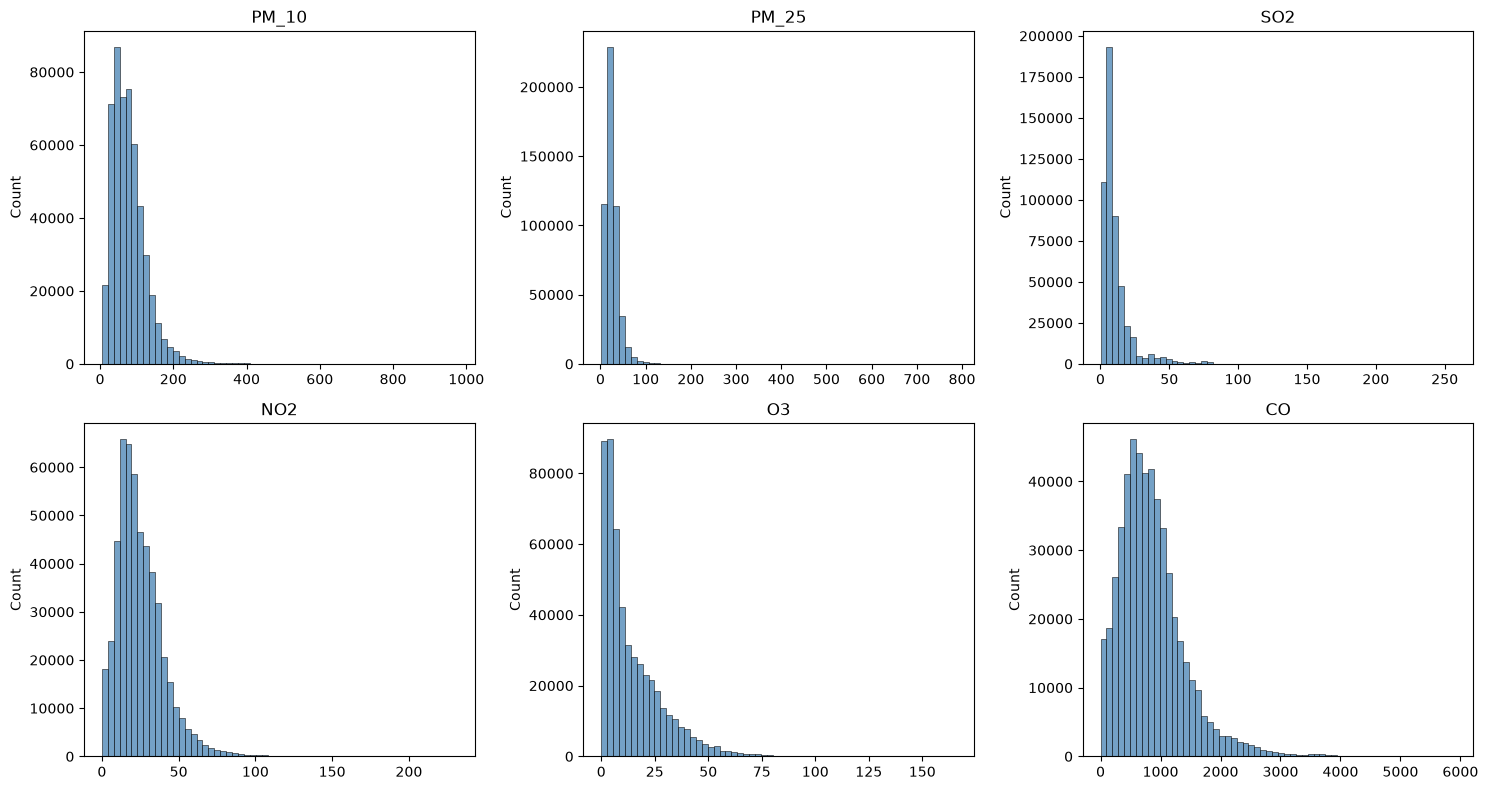

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, CONTAMINANTES):
    sns.histplot(df_full[col], bins=60, ax=ax, color="steelblue")
    ax.set_title(col.upper())
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

## EDA - Mapa de correlación

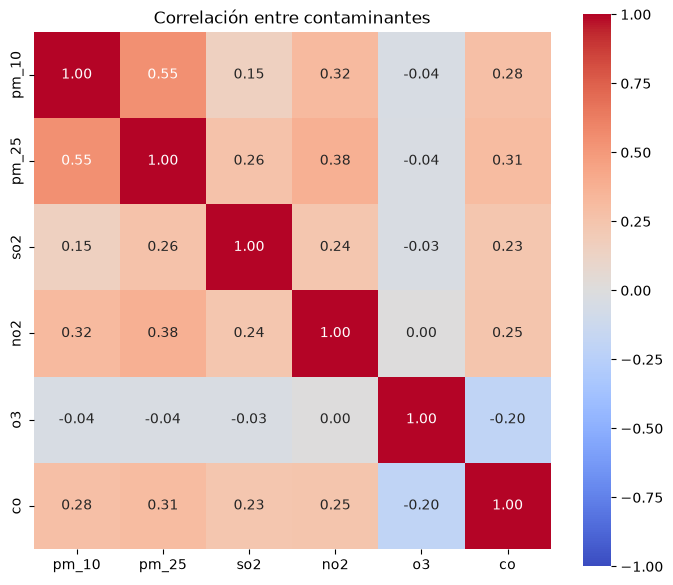

In [15]:
corr = df_full[CONTAMINANTES].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Correlación entre contaminantes")
plt.tight_layout()
plt.show()

## EDA - Boxplots por estación

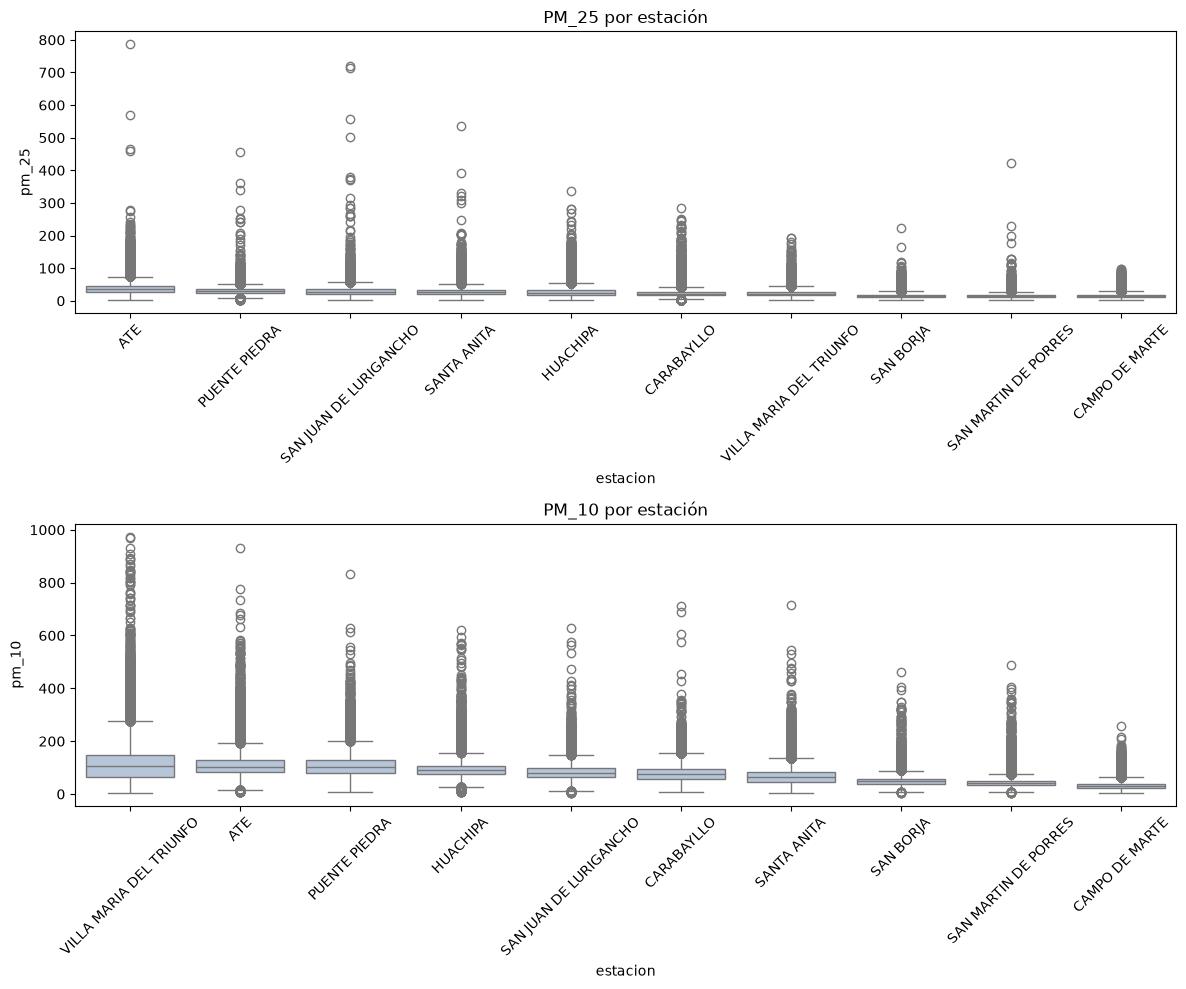

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))
for ax, col in zip(axes, ["pm_25", "pm_10"]):
    orden = df_full.groupby("estacion")[col].median().sort_values(ascending=False).index
    sns.boxplot(data=df_full, x="estacion", y=col, order=orden, ax=ax, color="lightsteelblue")
    ax.set_title(f"{col.upper()} por estación")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

### Detección de outliers

In [17]:
resumen_outliers = {}
for col in CONTAMINANTES:
    q1, q3 = df_full[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    es_outlier = (df_full[col] < lim_inf) | (df_full[col] > lim_sup)
    resumen_outliers[col] = {
        "lim_inf": round(lim_inf, 1),
        "lim_sup": round(lim_sup, 1),
        "n_outliers": int(es_outlier.sum()),
        "%_outliers": round(es_outlier.mean() * 100, 2),
    }
    df_full[f"{col}_outlier"] = es_outlier

pd.DataFrame(resumen_outliers).T

,lim_inf,lim_sup,n_outliers,%_outliers
pm_10,-42.3,187.6,14571.0,2.83
pm_25,-8.2,55.0,20186.0,3.92
so2,-6.8,23.9,37906.0,7.36
no2,-14.2,61.0,14506.0,2.82
o3,-21.9,46.9,18386.0,3.57
co,-467.2,2046.8,19083.0,3.71


In [18]:
outliers_pm25 = df_full[df_full["pm_25_outlier"]]
print("Outliers de pm_25 por mes (%, sobre el total de outliers de pm_25):")
print((outliers_pm25["mes"].value_counts(normalize=True).sort_index() * 100).round(1))

Outliers de pm_25 por mes (%, sobre el total de outliers de pm_25):
mes
1      2.8
2      2.8
3      4.2
4      9.3
5     14.4
6     13.5
7      8.7
8     10.3
9     10.7
10    11.9
11     6.5
12     4.9
Name: proportion, dtype: float64


## Preparación para clustering

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
scaler = StandardScaler()
X_full = scaler.fit_transform(df_full[CONTAMINANTES])

N_MUESTRA = 15000
idx_muestra = np.random.RandomState(SEED).choice(len(X_full), size=N_MUESTRA, replace=False)
X_muestra = X_full[idx_muestra]
print("X_full:", X_full.shape, "| X_muestra (solo viz/DBSCAN):", X_muestra.shape)

X_full: (514680, 6) | X_muestra (solo viz/DBSCAN): (15000, 6)


## Método del codo

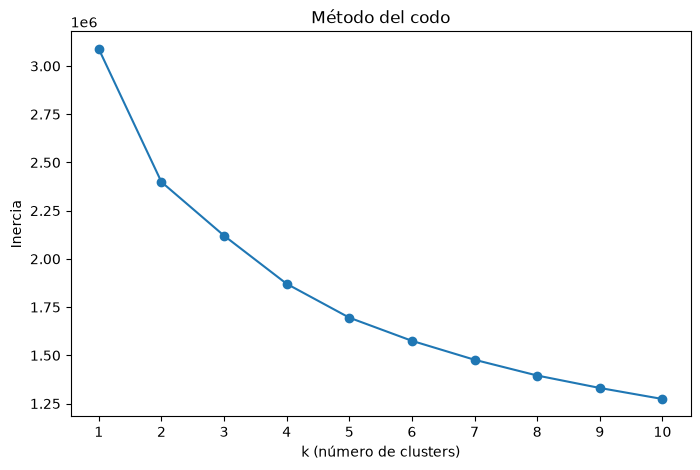

In [20]:
inercias = []
rango_k = range(1, 11)
for k in rango_k:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    km.fit(X_full)
    inercias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(rango_k), inercias, marker="o")
plt.xlabel("k (número de clusters)")
plt.ylabel("Inercia")
plt.title("Método del codo")
plt.xticks(list(rango_k))
plt.show()


## Coeficiente de silueta

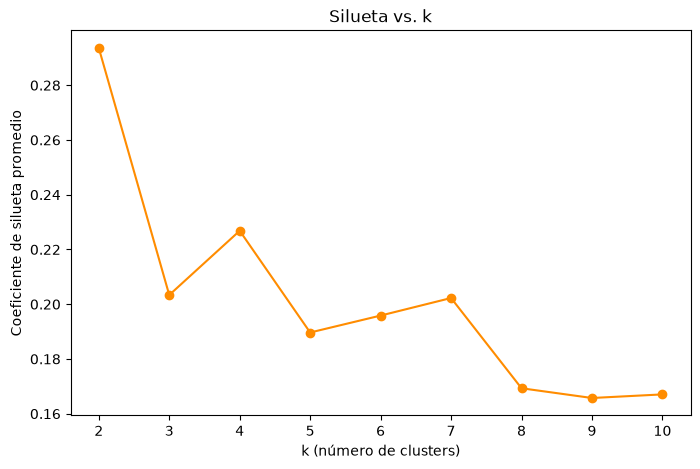

k=2: silueta = 0.294
k=3: silueta = 0.203
k=4: silueta = 0.227
k=5: silueta = 0.190
k=6: silueta = 0.196
k=7: silueta = 0.202
k=8: silueta = 0.169
k=9: silueta = 0.166
k=10: silueta = 0.167


In [21]:
siluetas = []
modelos = {}
rango_k_sil = range(2, 11)
for k in rango_k_sil:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_full)
    sil = silhouette_score(X_full, labels, sample_size=15000, random_state=SEED)
    siluetas.append(sil)
    modelos[k] = (km, labels)

plt.figure(figsize=(8, 5))
plt.plot(list(rango_k_sil), siluetas, marker="o", color="darkorange")
plt.xlabel("k (número de clusters)")
plt.ylabel("Coeficiente de silueta promedio")
plt.title("Silueta vs. k")
plt.xticks(list(rango_k_sil))
plt.show()

for k, s in zip(rango_k_sil, siluetas):
    print(f"k={k}: silueta = {s:.3f}")

## K-means final

In [22]:
K_FINAL = int(list(rango_k_sil)[int(np.argmax(siluetas))])
print("K_FINAL elegido:", K_FINAL)

kmeans_final, labels_full = modelos[K_FINAL]
df_full["cluster"] = labels_full

silueta_final = silhouette_score(X_full, labels_full, sample_size=15000, random_state=SEED)
print(f"Silueta con k={K_FINAL} (muestreada): {silueta_final:.3f}")
print("\nTamaño de cada cluster (dataset completo):")
print(df_full["cluster"].value_counts().sort_index())

K_FINAL elegido: 2


Silueta con k=2 (muestreada): 0.294

Tamaño de cada cluster (dataset completo):
cluster
0    160036
1    354644
Name: count, dtype: int64


## Visualización PCA

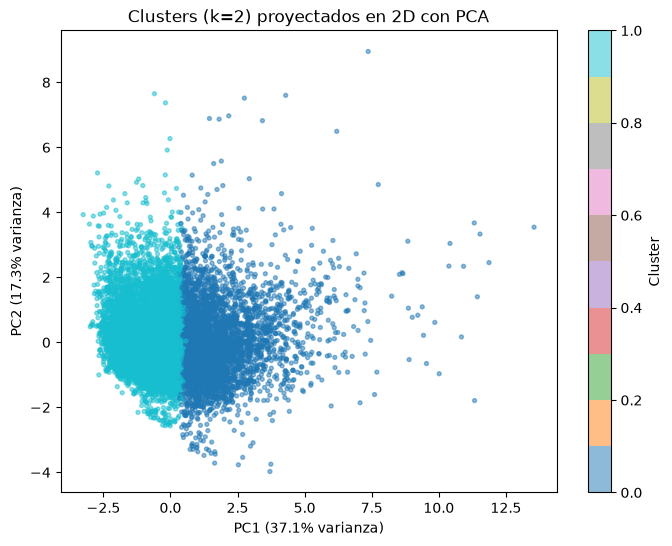

In [23]:
pca = PCA(n_components=2, random_state=SEED)
X_pca_muestra = pca.fit_transform(X_muestra)
labels_muestra = labels_full[idx_muestra]

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca_muestra[:, 0], X_pca_muestra[:, 1], c=labels_muestra, cmap="tab10", s=8, alpha=0.5)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)")
plt.title(f"Clusters (k={K_FINAL}) proyectados en 2D con PCA")
plt.colorbar(scatter, label="Cluster")
plt.show()